## Animal Crossing New Horizons Villager Analysis

### Goals <a class='anchor' id='Goals'></a>
<ul>
    <li>Become familiar with the data</li>
    <li>Clean and prepare the data for analysis</li>
    <li>Investigate the data and determine potential anaylsis points</li>
    <li>Review variables based on conceived anaysis points</li>
</ul>

### Data <a class='anchor' id='Data'></a>

The data was gathered from Kaggle. 

Additional information about the data set, including it's creator and column descriptions, can be found here: https://www.kaggle.com/datasets/jessicali9530/animal-crossing-new-horizons-nookplaza-dataset?select=villagers.csv

Note: this does not include content of any new villagers after the initial game launch in 2020. Three updates were launched on 3/2021, 11/2021, and 1/2026, which added additonal villagers through amiibos. (source: https://www.ign.com/wikis/animal-crossing-new-horizons/Villager_List:_All_Villagers_and_Special_Characters)



#### Loading the Data <a class='anchor' id='Loading'></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
villagers = pd.read_csv('villagers.csv')

#### Inspecting and Cleaning the Data <a class='anchor' id='Inspect'></a>

In [3]:
villagers.head()

,Name,Species,Gender,Personality,Hobby,Birthday,Catchphrase,Favorite Song,Style 1,Style 2,Color 1,Color 2,Wallpaper,Flooring,Furniture List,Filename,Unique Entry ID
0,Admiral,Bird,Male,Cranky,Nature,27-Jan,aye aye,Steep Hill,Cool,Cool,Black,Blue,dirt-clod wall,tatami,717;1849;7047;2736;787;5970;3449;3622;3802;410...,brd06,B3RyfNEqwGmcccRC3
1,Agent S,Squirrel,Female,Peppy,Fitness,2-Jul,sidekick,Go K.K. Rider,Active,Simple,Blue,Black,concrete wall,colorful tile flooring,7845;7150;3468;4080;290;3971;3449;1708;4756;25...,squ05,SGMdki6dzpDZyXAw5
2,Agnes,Pig,Female,Big Sister,Play,21-Apr,snuffle,K.K. House,Simple,Elegant,Pink,White,gray molded-panel wall,arabesque flooring,4129;7236;7235;7802;896;3428;4027;7325;3958;71...,pig17,jzWCiDPm9MqtCfecP
3,Al,Gorilla,Male,Lazy,Fitness,18-Oct,ayyyeee,Go K.K. Rider,Active,Active,Red,White,concrete wall,green rubber flooring,1452;4078;4013;833;4116;3697;7845;3307;3946;39...,gor08,LBifxETQJGEaLhBjC
4,Alfonso,Alligator,Male,Lazy,Play,9-Jun,it'sa me,Forest Life,Simple,Simple,Red,Blue,yellow playroom wall,green honeycomb tile,4763;3205;3701;1557;3623;85;3208;3584;4761;121...,crd00,REpd8KxB8p9aGBRSE


In [4]:
villagers.shape

(391, 17)

#### Adjust Column Names <a class='anchor' id='Columns'></a>

In [5]:
#adjust column names for easier use
villagers = villagers.rename(columns = {'Favorite Song': 'favorite_song', 'Style 1': 'style1','Style 2': 'style2', 'Color 1': 'color1', 'Color 2': 'color2','Furniture List': 'furniture_list', 'Unique Entry ID': 'unique_ID'})
print(villagers.head())

      Name    Species  Gender Personality    Hobby Birthday Catchphrase  \
0  Admiral       Bird    Male      Cranky   Nature   27-Jan     aye aye   
1  Agent S   Squirrel  Female       Peppy  Fitness    2-Jul    sidekick   
2    Agnes        Pig  Female  Big Sister     Play   21-Apr     snuffle   
3       Al    Gorilla    Male        Lazy  Fitness   18-Oct     ayyyeee   
4  Alfonso  Alligator    Male        Lazy     Play    9-Jun    it'sa me   

   favorite_song  style1   style2 color1 color2               Wallpaper  \
0     Steep Hill    Cool     Cool  Black   Blue          dirt-clod wall   
1  Go K.K. Rider  Active   Simple   Blue  Black           concrete wall   
2     K.K. House  Simple  Elegant   Pink  White  gray molded-panel wall   
3  Go K.K. Rider  Active   Active    Red  White           concrete wall   
4    Forest Life  Simple   Simple    Red   Blue    yellow playroom wall   

                 Flooring                                     furniture_list  \
0                 

#### Check Column Data Validity <a class='anchor' id='data_validity'></a>

In [6]:
#review data types for each column 
villagers.info()
#double check for any null values
villagers.isnull().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            391 non-null    object
 1   Species         391 non-null    object
 2   Gender          391 non-null    object
 3   Personality     391 non-null    object
 4   Hobby           391 non-null    object
 5   Birthday        391 non-null    object
 6   Catchphrase     391 non-null    object
 7   favorite_song   391 non-null    object
 8   style1          391 non-null    object
 9   style2          391 non-null    object
 10  color1          391 non-null    object
 11  color2          391 non-null    object
 12  Wallpaper       391 non-null    object
 13  Flooring        391 non-null    object
 14  furniture_list  391 non-null    object
 15  Filename        391 non-null    object
 16  unique_ID       391 non-null    object
dtypes: object(17)
memory usage: 52.1+ KB


Name              False
Species           False
Gender            False
Personality       False
Hobby             False
Birthday          False
Catchphrase       False
favorite_song     False
style1            False
style2            False
color1            False
color2            False
Wallpaper         False
Flooring          False
furniture_list    False
Filename          False
unique_ID         False
dtype: bool

In [7]:
#all columns appear to be the correct data type
#no null values throughout data

In [8]:
#check for duplicates using unique entry ID
check_for_duplicates = villagers['unique_ID'].duplicated()
print(check_for_duplicates)
print(check_for_duplicates.unique())

0      False
1      False
2      False
3      False
4      False
       ...  
386    False
387    False
388    False
389    False
390    False
Name: unique_ID, Length: 391, dtype: bool
[False]


In [9]:
#check species, gender and personality, hobby, style 1, style 2 to ensure all values align with correct in game values
#per https://animalcrossing.fandom.com/wiki/Villager#Personalities the following traits should be identified: 
female_personalities = ['Snooty', 'Normal', 'Peppy', 'Big Sister']
male_personalities = ['Cranky', 'Lazy', 'Jock', 'Smug']

#check female personalities
female_villagers = villagers[villagers.Gender == 'Female']
female_villager_personalities = female_villagers.Personality.unique() 
print(sorted(female_villager_personalities) == sorted(female_personalities))

#check male personalities
male_villagers = villagers[villagers.Gender == 'Male']
male_villager_personalities = male_villagers.Personality.unique()
print(sorted(male_villager_personalities) == sorted(male_personalities))


True
True


In [10]:
#check hobbies 
#per https://animalcrossing.fandom.com/wiki/Hobbies the following hobbies should be identified: 
hobbies = ['Education', 'Fashion', 'Fitness', 'Music', 'Nature', 'Play']

villager_hobbies = villagers.Hobby.unique()
sorted(villager_hobbies) == sorted(hobbies)

True

In [11]:
#check species
#per https://animalcrossing.fandom.com/wiki/Species the following species should be identifed: 
species = ['Alligator', 'Anteater', 'Bear', 'Bird', 'Bull', 'Cat', 'Chicken', 'Cow', 'Cub', 'Deer', 'Dog', 'Duck', 'Eagle', 'Elephant','Frog', 'Goat', 'Gorilla', 'Hamster', 'Hippo', 'Horse', 'Kangaroo', 'Koala', 'Lion', 'Monkey', 'Mouse', 'Octopus', 'Ostrich', 'Penguin', 'Pig', 'Rabbit','Rhino', 'Sheep', 'Squirrel', 'Tiger', 'Wolf']

villager_species = villagers.Species.unique()
sorted(villager_species) == sorted(species)


True

In [12]:
#check styles 1 and 2
# per https://strategywiki.org/wiki/Animal_Crossing:_New_Horizons/Clothing both styles 1 and 2 should include the following: 
styles = ['Simple', 'Active', 'Cool', 'Cute', 'Elegant', 'Gorgeous']

style1_types = villagers.style1.unique()
style2_types = villagers.style2.unique()

print(sorted(style1_types) == sorted(styles))
print(sorted(style2_types) == sorted(styles))

True
True


In [13]:
#check color values to ensure each entry is a color
colors1_options = villagers.color1.unique()
colors2_options = villagers.color2.unique()

print(colors1_options, colors2_options)


['Black' 'Blue' 'Pink' 'Red' 'Yellow' 'Green' 'Colorful' 'Light blue'
 'Orange' 'Purple' 'Brown' 'Beige' 'White' 'Gray'] ['Blue' 'Black' 'White' 'Pink' 'Brown' 'Orange' 'Purple' 'Red' 'Colorful'
 'Gray' 'Green' 'Yellow' 'Beige' 'Light blue']


In [14]:
#check birthdays to ensure consistent format
villagers[['day', 'year']] = villagers.Birthday.str.split('-', expand = True)
#print(villagers.head())
print(villagers['year'].unique())
print(villagers['day'].unique())

['Jan' 'Jul' 'Apr' 'Oct' 'Jun' 'Aug' 'Nov' 'Feb' 'Mar' 'Sep' 'Dec' 'May']
['27' '2' '21' '18' '9' '19' '8' '16' '4' '30' '24' '22' '6' '20' '31'
 '28' '23' '7' '15' '5' '10' '3' '25' '12' '13' '29' '1' '26' '14' '17'
 '11']


#### Initial Data Observations and Possible Points of Interest <a class='anchor' id='initial_observations'></a>
<ul>
<li>What are the least/most common species type, trait, personality, etc.? </li>
<li>Does species type influence personality, hobby, or style choices? </li>
<li>What does the zodiac sign distribution for all villagers vs villagers of specific species look like? </li>
</ul>

### Exploratory Data Analysis <a class='anchor' id='exploratory_analysis'></a>

#### Species Analysis <a class='anchor' id='species'></a>

Species
Cat          23
Rabbit       20
Squirrel     18
Frog         18
Duck         17
Dog          16
Cub          16
Bear         15
Pig          15
Horse        15
Mouse        15
Bird         13
Penguin      13
Sheep        13
Wolf         11
Elephant     11
Deer         10
Ostrich      10
Gorilla       9
Chicken       9
Eagle         9
Koala         9
Goat          8
Kangaroo      8
Monkey        8
Hamster       8
Alligator     7
Lion          7
Anteater      7
Hippo         7
Tiger         7
Bull          6
Rhino         6
Cow           4
Octopus       3
Name: count, dtype: int64

The most common species is Cat and least common species is Octopus.



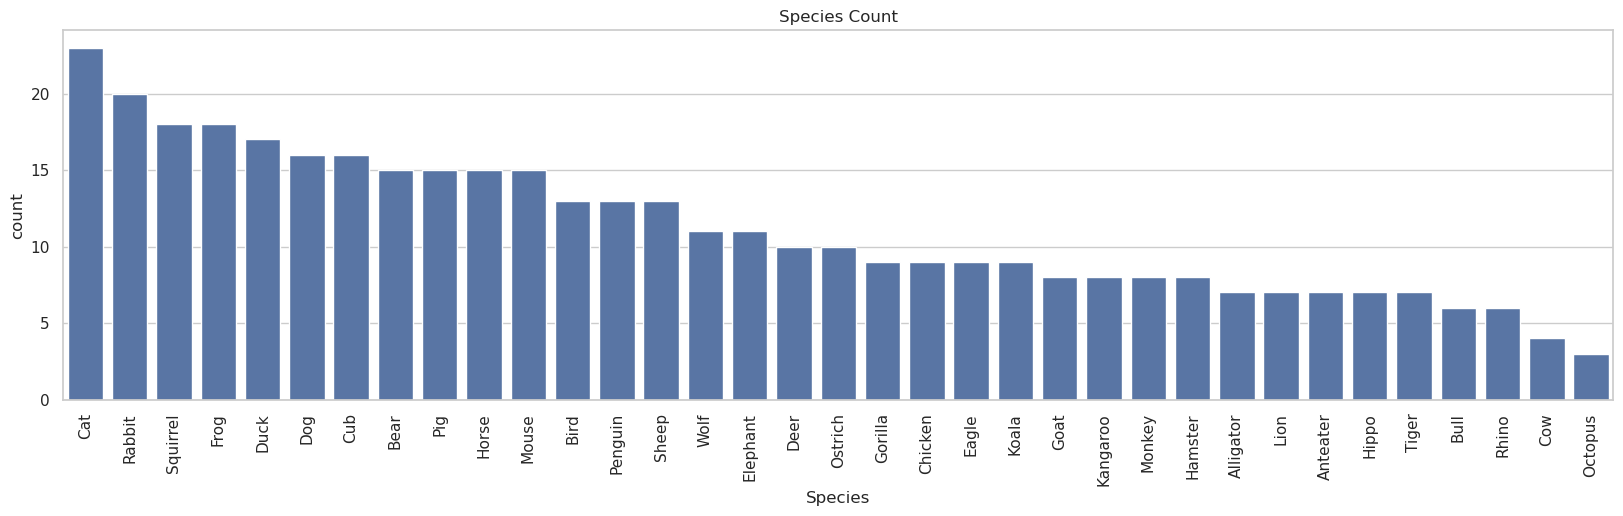

In [15]:
#What species is most common? Which is least common? 

species_dist = villagers['Species'].value_counts()
print(species_dist)

print()

print("The most common species is Cat and least common species is Octopus.")

print()

#visualize species count
sns.set_theme(style="whitegrid")
plt.figure().set_figwidth(20)
sns.countplot(x = 'Species', data = villagers, order = villagers['Species'].value_counts().index)
plt.title('Species Count')
plt.xticks(rotation=90)
plt.show()


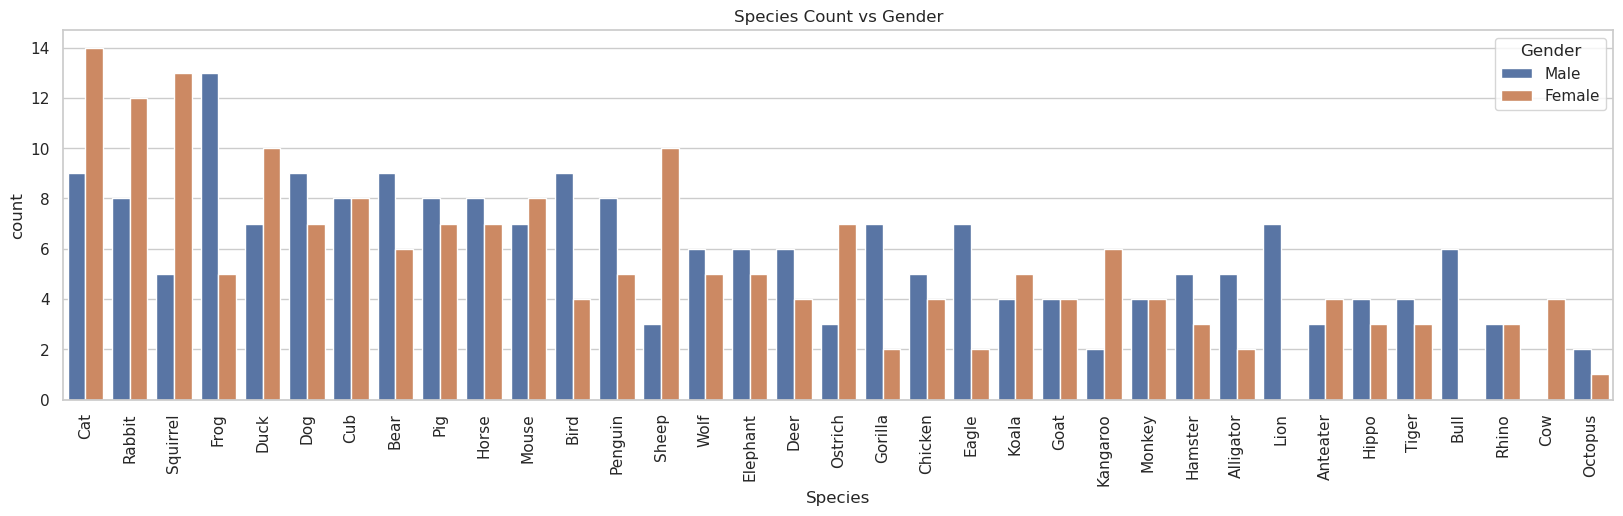

In [16]:
#Visualize species vs gender counts

sns.set_theme(style="whitegrid")
plt.figure().set_figwidth(20)
sns.countplot(x = 'Species', data = villagers, order = villagers['Species'].value_counts().index, hue = 'Gender')
plt.title('Species Count vs Gender')
plt.xticks(rotation=90)
plt.show()

['Bird' 'Squirrel' 'Pig' 'Gorilla' 'Alligator' 'Koala' 'Eagle' 'Anteater'
 'Cow/Bull' 'Mouse' 'Cat' 'Horse' 'Hamster' 'Kangaroo' 'Wolf' 'Penguin'
 'Chicken' 'Elephant' 'Sheep' 'Deer' 'Tiger' 'Cub' 'Dog' 'Bear' 'Hippo'
 'Duck' 'Goat' 'Ostrich' 'Rabbit' 'Lion' 'Frog' 'Monkey' 'Rhino' 'Octopus']

Updated Species Count bar graph:


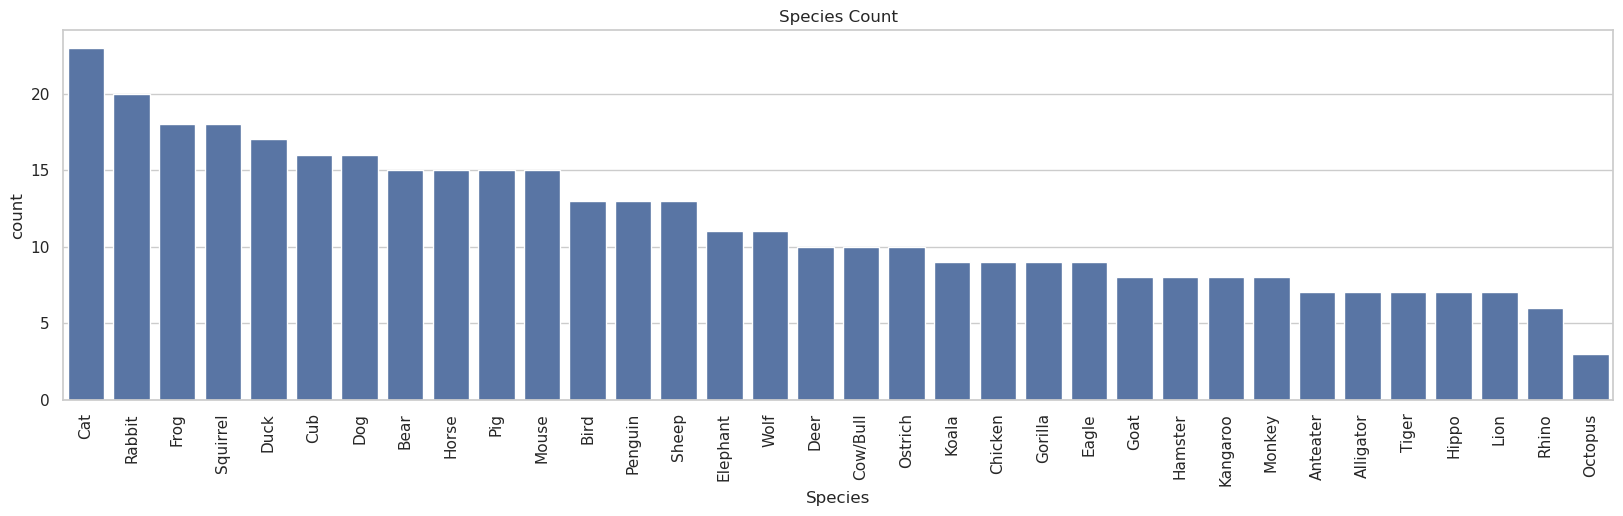


Updated Species Count vs Gender bar graph:


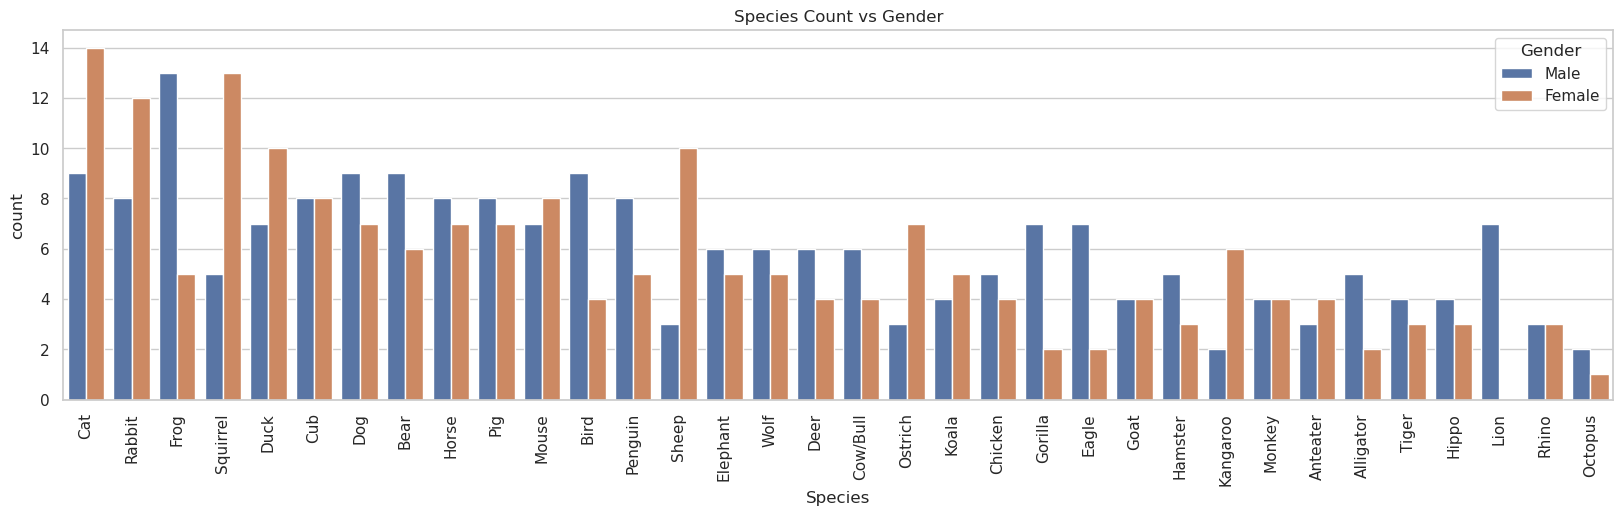

In [17]:
#Lion, Cow, and Bull only have one gender variation. Let's combine cows and bulls as they are the same species, just different gender counterparts.

villagers['Species'] = villagers['Species'].replace({'Cow': 'Cow/Bull', 'Bull': 'Cow/Bull'})
print(villagers.Species.unique())

print()

#Update Species Count and Species Count vs Gender graphs
print('Updated Species Count bar graph:')
#visualize species count
sns.set_theme(style="whitegrid")
plt.figure().set_figwidth(20)
sns.countplot(x = 'Species', data = villagers, order = villagers['Species'].value_counts().index)
plt.title('Species Count')
plt.xticks(rotation=90)
plt.show()

print()

print('Updated Species Count vs Gender bar graph:')
#visualize species count vs gender counts
sns.set_theme(style="whitegrid")
plt.figure().set_figwidth(20)
sns.countplot(x = 'Species', data = villagers, order = villagers['Species'].value_counts().index, hue = 'Gender')
plt.title('Species Count vs Gender')
plt.xticks(rotation=90)
plt.show()

In [18]:
#Identify most common top 10 species
species_count = villagers.Species.value_counts().head(10)
top_10_species_list = species_count.index.tolist()
print(top_10_species_list)

top_10_species_df = villagers[(villagers.Species == 'Cat') | (villagers.Species == 'Rabbit') | (villagers.Species == 'Frog') | (villagers.Species == 'Squirrel') | (villagers.Species == 'Duck') | (villagers.Species == 'Cub') | (villagers.Species == 'Dog') | (villagers.Species == 'Bear') | (villagers.Species == 'Horse') | (villagers.Species == 'Pig')]


['Cat', 'Rabbit', 'Frog', 'Squirrel', 'Duck', 'Cub', 'Dog', 'Bear', 'Horse', 'Pig']


#### Personality Analysis <a class='anchor' id='personality'></a>

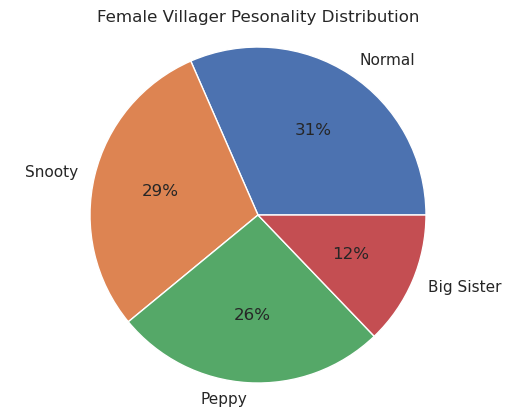

The most common female personality type is Normal and the least common female personality type is Big Sister.



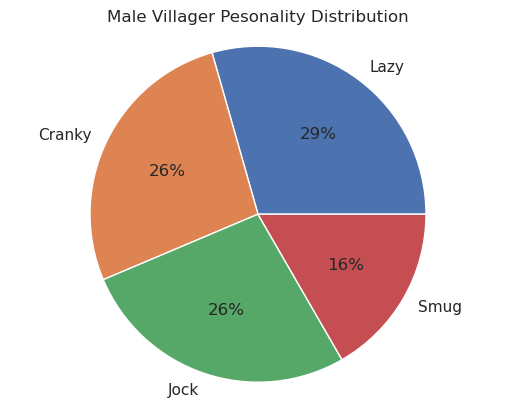

The most common male personality type is Lazy and least common male personality type is Smug.


<Figure size 640x480 with 0 Axes>

In [19]:
#What personality is most common? Which is least common? 

#prepare gender specific personality data for visualization
female_villagers = villagers[villagers['Gender'] == 'Female']
female_personality = female_villagers[['Personality']]

male_villagers = villagers[villagers['Gender'] == 'Male']
male_personality = male_villagers[['Personality']]

#female villager vizualization
plt.pie(female_personality.value_counts(), autopct = '%d%%', labels = ['Normal', 'Snooty', 'Peppy', 'Big Sister'])
plt.title('Female Villager Pesonality Distribution')
plt.axis('Equal')
plt.show()
plt.clf()
print("The most common female personality type is Normal and the least common female personality type is Big Sister.")

print()

#male villager vizualization
plt.pie(male_personality.value_counts(), autopct = '%d%%', labels = ['Lazy', 'Cranky', 'Jock', 'Smug'])
plt.title('Male Villager Pesonality Distribution')
plt.axis('Equal')
plt.show()
plt.clf()
print("The most common male personality type is Lazy and least common male personality type is Smug.")


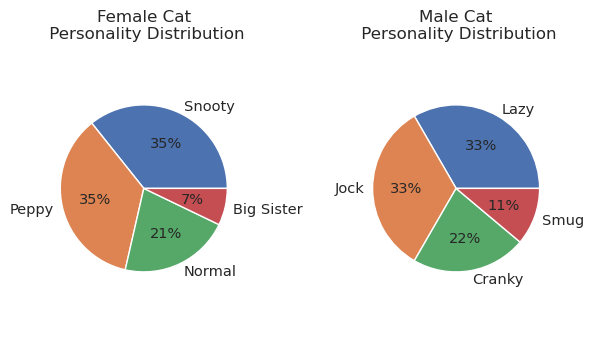

None


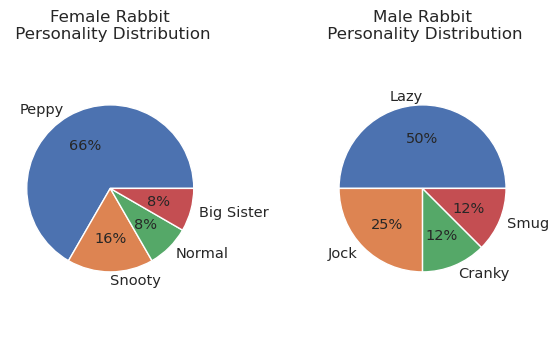

None


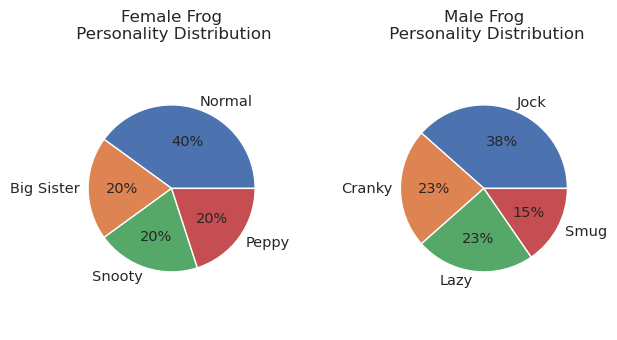

None


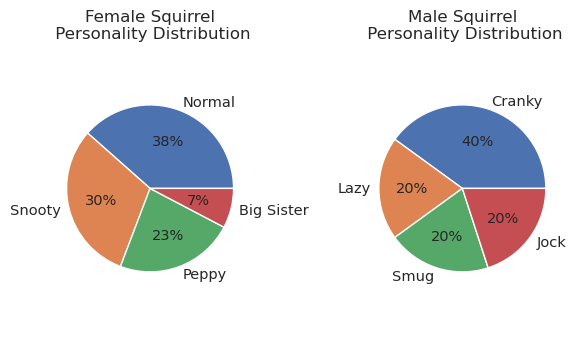

None


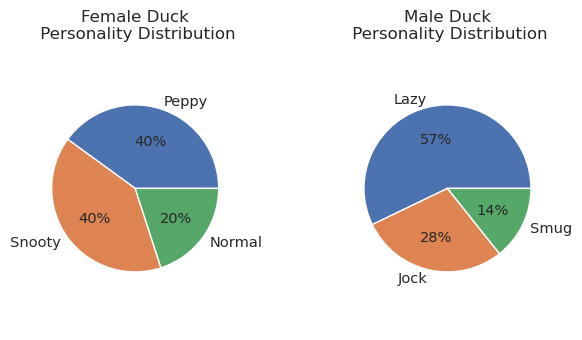

None


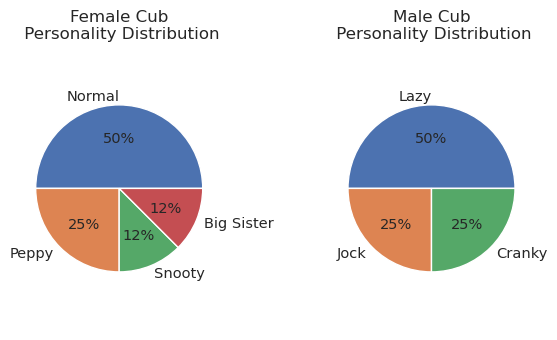

None


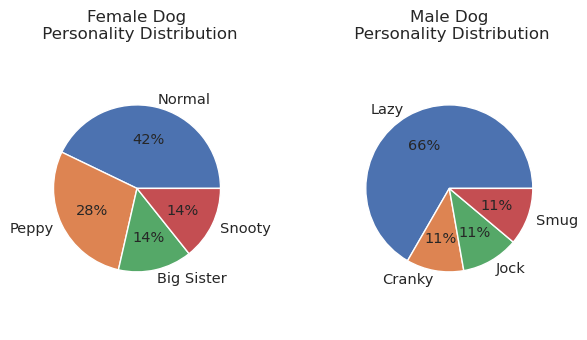

None


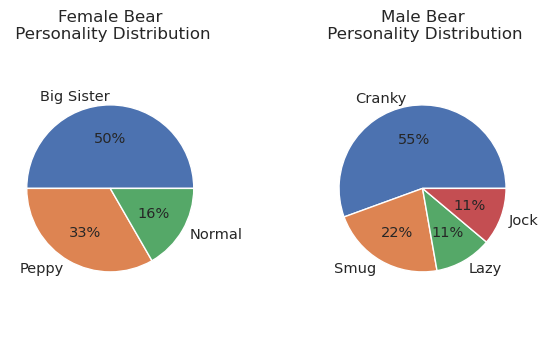

None


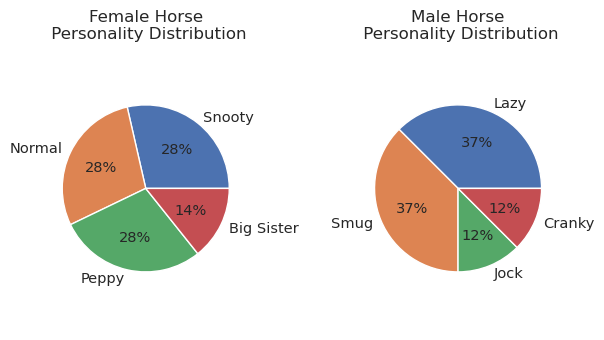

None


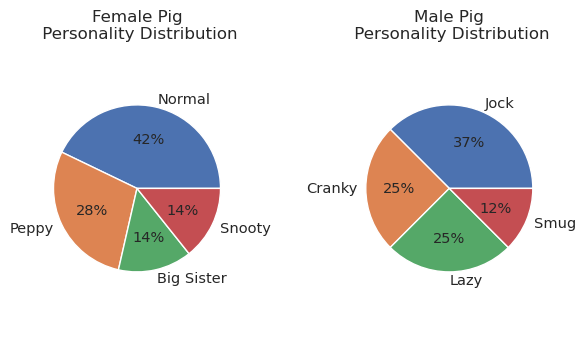

None


In [20]:
#Visualization of personalities per top_10_species

def gender_species_personality_pie(species): 
    data = villagers[(villagers.Species == species)]
    female_data = data[(data.Gender == 'Female')]
    male_data = data[(data.Gender == 'Male')]
    female_pie_labels = female_data.Personality.value_counts().index.tolist()
    male_pie_labels = male_data.Personality.value_counts().index.tolist()
    
    plt.subplot(1, 2, 1)
    plt.pie(female_data.Personality.value_counts(), autopct = '%d%%', labels = female_pie_labels, textprops = {'fontsize': 10.5})
    plt.axis('Equal')
    plt.title("Female " + species +  "\n Personality Distribution")

    plt.subplot(1, 2, 2)
    plt.pie(male_data.Personality.value_counts(), autopct = '%d%%', labels = male_pie_labels, textprops = {'fontsize': 10.5})
    plt.axis('Equal')
    plt.title("Male " + species + "\n Personality Distribution")

    plt.subplots_adjust(wspace = .70, top = .7)
    plt.show()

for i in top_10_species_list: 
    print(gender_species_personality_pie(i))

<Axes: title={'center': 'Top 10 Species Male Personalities'}, xlabel='Species'>

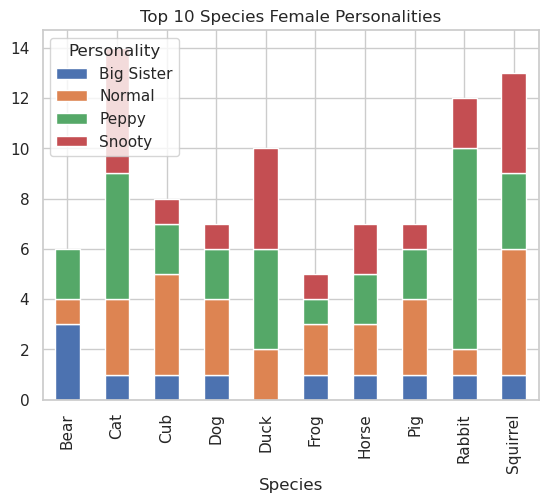

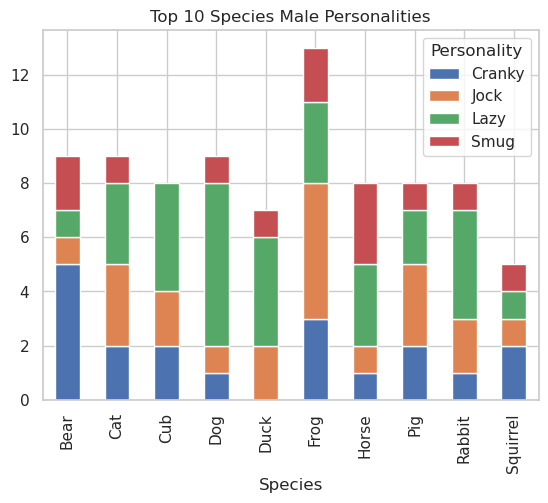

In [21]:
#Summary visualization of personalities per top_10_species_df

female_data = top_10_species_df[(top_10_species_df.Gender == 'Female')]
male_data = top_10_species_df[(top_10_species_df.Gender == 'Male')]
    

female_data.groupby(['Species', 'Personality']).size().unstack().plot(kind='bar', stacked = True, title = 'Top 10 Species Female Personalities')

male_data.groupby(['Species', 'Personality']).size().unstack().plot(kind='bar', stacked = True, title = 'Top 10 Species Male Personalities')


#### Hobby Analysis <a class='anchor' id='hobby'></a>

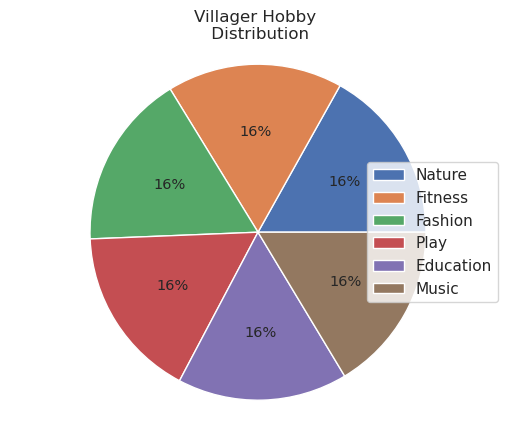

<Figure size 640x480 with 0 Axes>

In [22]:
#Analyze villager hobbies 

pie_labels = villagers.Hobby.value_counts().index.tolist()
plt.subplot(1,1,1)    
plt.pie(villagers.Hobby.value_counts(), autopct = '%d%%', labels = pie_labels, textprops = {'fontsize': 10.5}, labeldistance = None)
plt.axis('Equal')
plt.legend(pie_labels, loc = 'center right')
plt.title("Villager Hobby \n Distribution")
plt.show()
plt.clf()

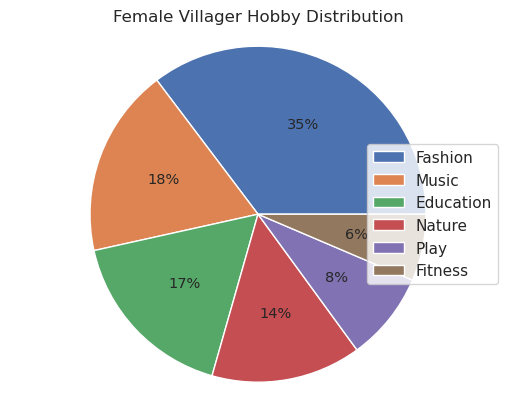


The most common female hobby is Fashion and the least common female hobby type is Fitness



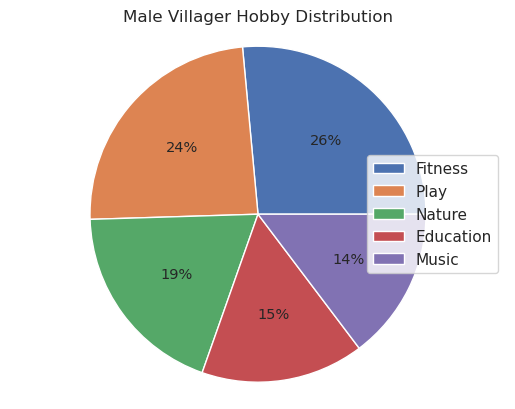


The most common male hobby is Fitness and the least common male hobby type is Music


<Figure size 640x480 with 0 Axes>

In [23]:
#Analyze villager hobbies per gender

#female hobby distribution
female_pie_labels = female_villagers.Hobby.value_counts().index.tolist()  
plt.pie(female_villagers.Hobby.value_counts(), autopct = '%d%%', labels = female_pie_labels, textprops = {'fontsize': 10.5}, labeldistance = None)
plt.axis('Equal')
plt.legend(female_pie_labels, loc = 'center right')
plt.title("Female Villager Hobby Distribution")
plt.show()
plt.clf()

print()
print("The most common female hobby is Fashion and the least common female hobby type is Fitness")
print()

#male hobby distribution  
male_pie_labels = male_villagers.Hobby.value_counts().index.tolist() 
plt.pie(male_villagers.Hobby.value_counts(), autopct = '%d%%', textprops = {'fontsize': 10.5}, labeldistance = None)
plt.axis('Equal')
plt.legend(male_pie_labels, loc = 'center right')
plt.title("Male Villager Hobby Distribution")
plt.show()
plt.clf()

print()
print("The most common male hobby is Fitness and the least common male hobby type is Music")


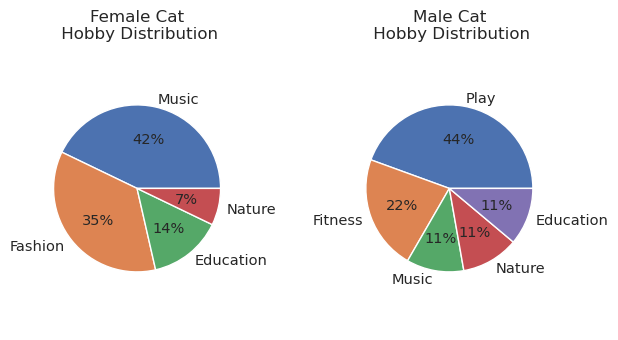

None


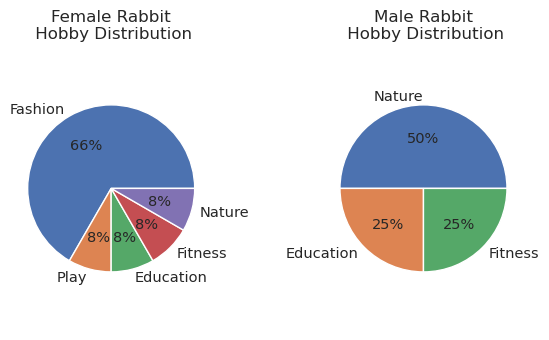

None


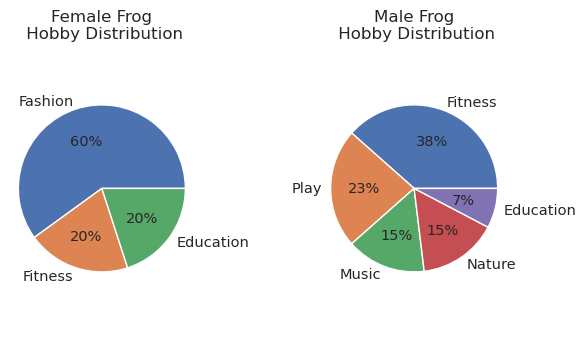

None


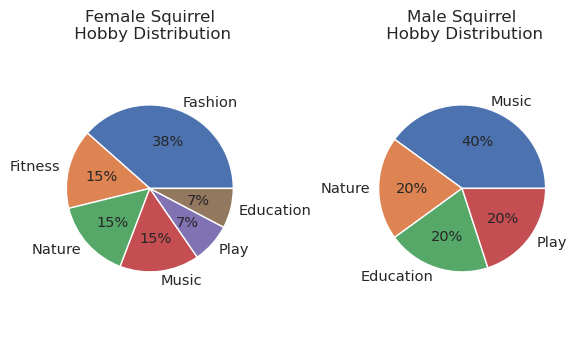

None


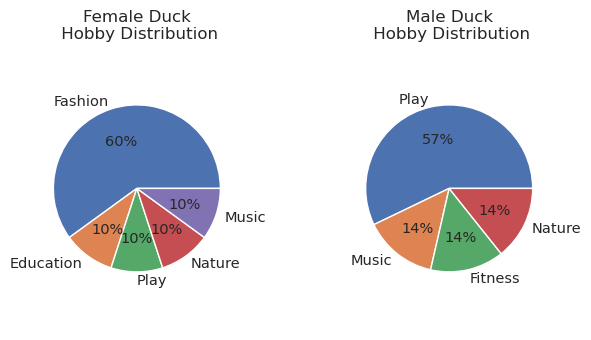

None


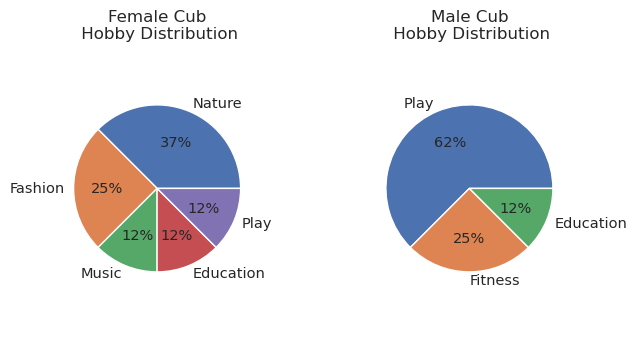

None


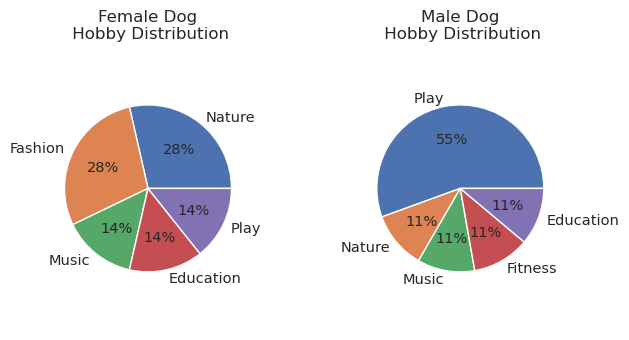

None


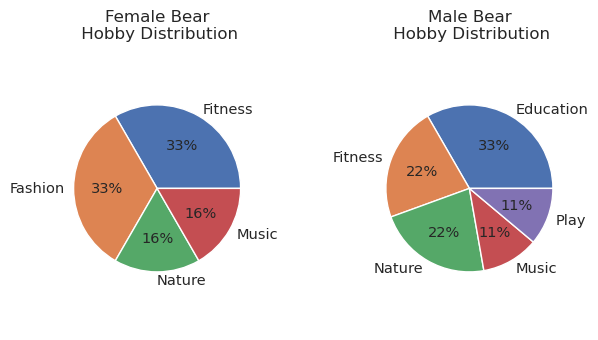

None


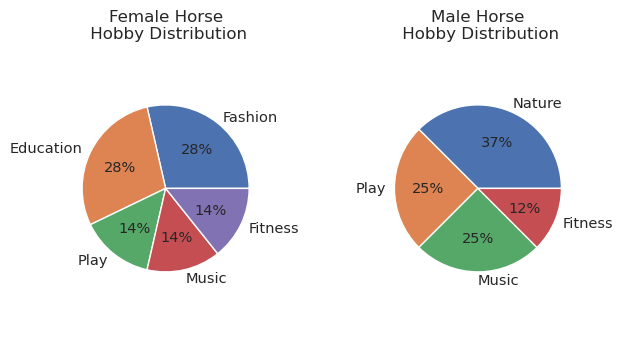

None


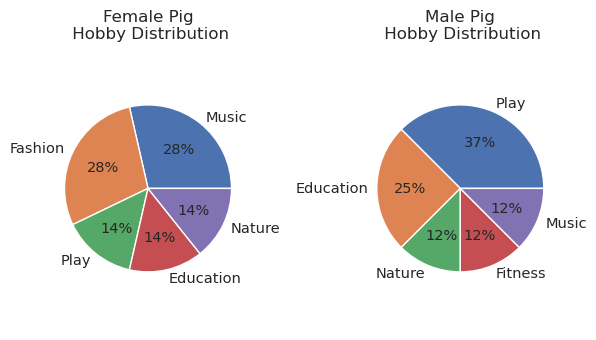

None


In [24]:
#Analyze hobby distribution per top_10_species_df
def species_hobby_pie(species): 
    data = villagers[(villagers.Species == species)]
    female_data = data[(data.Gender == 'Female')]
    male_data = data[(data.Gender == 'Male')]
    female_labels = female_data.Hobby.value_counts().index.tolist()
    male_labels = male_data.Hobby.value_counts().index.tolist()
    
    plt.subplot(1, 2, 1)
    plt.pie(female_data.Hobby.value_counts(), autopct = '%d%%', labels = female_labels, textprops = {'fontsize': 10.5})
    plt.axis('Equal')
    plt.title("Female " + species +  "\n Hobby Distribution")

    plt.subplot(1, 2, 2)
    plt.pie(male_data.Hobby.value_counts(), autopct = '%d%%', labels = male_labels, textprops = {'fontsize': 10.5})
    plt.axis('Equal')
    plt.title("Male " + species + "\n Hobby Distribution")

    plt.subplots_adjust(wspace = .70, top = .7)
    plt.show()

for i in top_10_species_list: 
    print(species_hobby_pie(i))

<Axes: title={'center': 'Top 10 Species Male Hobby Distribution'}, ylabel='Species'>

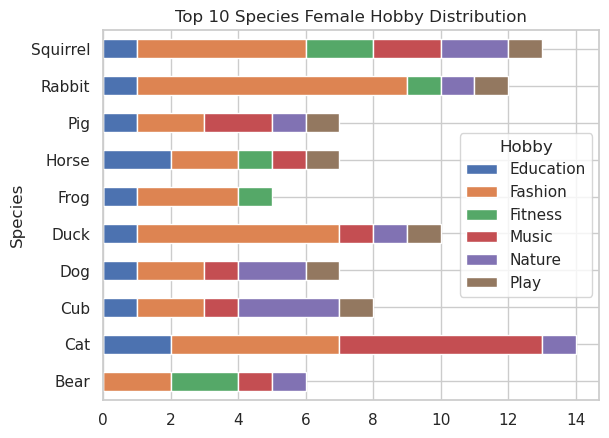

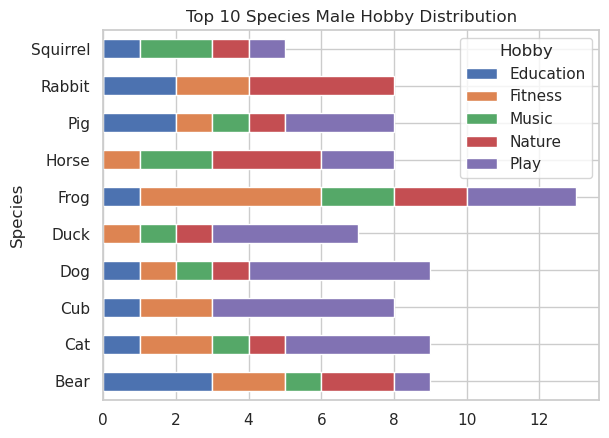

In [25]:
#Summary visualization of hobbies per top_10_species_df

female_data.groupby(['Species', 'Hobby']).size().unstack().plot.barh(stacked = True, title = 'Top 10 Species Female Hobby Distribution', legend = 'center')
male_data.groupby(['Species', 'Hobby']).size().unstack().plot.barh(stacked = True, title = 'Top 10 Species Male Hobby Distribution', legend = 'center')


#### Zodiac Sign Analysis <a class='anchor' id='zodiac'></a>

In [26]:
#Convert the Birthday column from string to date format for Zodiac Sign assignment
villagers['Birthday'] = pd.to_datetime(villagers['Birthday'], format = '%d-%b')
print(villagers.Birthday.head())

0   1900-01-27
1   1900-07-02
2   1900-04-21
3   1900-10-18
4   1900-06-09
Name: Birthday, dtype: datetime64[ns]


/tmp/ipykernel_11128/3182230444.py:2: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  villagers['Birthday'] = pd.to_datetime(villagers['Birthday'], format = '%d-%b')


In [27]:
#Determine the Zodiac signs of the villagers

#convert birthdays to month - day foramt
villagers['Birthday'] = villagers['Birthday'].dt.strftime('%m-%d')
print(villagers.Birthday.head())
#filter using loc for Zodiac Sign
villagers.loc[(villagers['Birthday'] >= '12-22') & (villagers['Birthday'] <= '01-20'), 'zodiac_sign'] = 'Capricorn'
villagers.loc[(villagers['Birthday'] >= '01-21') & (villagers['Birthday'] <= '02-18'), 'zodiac_sign'] = 'Aquarius'
villagers.loc[(villagers['Birthday'] >= '02-19') & (villagers['Birthday'] <= '03-20'), 'zodiac_sign'] = 'Pisces'
villagers.loc[(villagers['Birthday'] >= '03-21') & (villagers['Birthday'] <= '04-20'), 'zodiac_sign'] = 'Aries'
villagers.loc[(villagers['Birthday'] >= '04-21') & (villagers['Birthday'] <= '05-20'), 'zodiac_sign'] = 'Taurus'
villagers.loc[(villagers['Birthday'] >= '05-21') & (villagers['Birthday'] <= '06-21'), 'zodiac_sign'] = 'Gemini'
villagers.loc[(villagers['Birthday'] >= '06-22') & (villagers['Birthday'] <= '07-22'), 'zodiac_sign'] = 'Cancer'
villagers.loc[(villagers['Birthday'] >= '07-23') & (villagers['Birthday'] <= '08-22'), 'zodiac_sign'] = 'Leo'
villagers.loc[(villagers['Birthday'] >= '08-23') & (villagers['Birthday'] <= '09-22'), 'zodiac_sign'] = 'Virgo'
villagers.loc[(villagers['Birthday'] >= '09-23') & (villagers['Birthday'] <= '10-22'), 'zodiac_sign'] = 'Libra'
villagers.loc[(villagers['Birthday'] >= '10-23') & (villagers['Birthday'] <= '11-22'), 'zodiac_sign'] = 'Scorpio'
villagers.loc[(villagers['Birthday'] >= '11-23') & (villagers['Birthday'] <= '12-21'), 'zodiac_sign'] = 'Sagittarius'

0    01-27
1    07-02
2    04-21
3    10-18
4    06-09
Name: Birthday, dtype: object


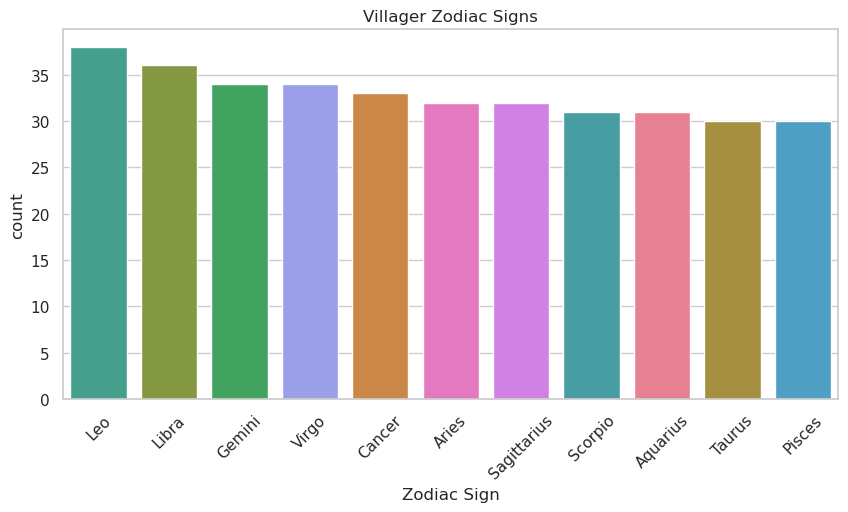

zodiac_sign
Leo            38
Libra          36
Gemini         34
Virgo          34
Cancer         33
Aries          32
Sagittarius    32
Scorpio        31
Aquarius       31
Taurus         30
Pisces         30
Name: count, dtype: int64 zodiac_sign
Leo            0.105263
Libra          0.099723
Gemini         0.094183
Virgo          0.094183
Cancer         0.091413
Aries          0.088643
Sagittarius    0.088643
Scorpio        0.085873
Aquarius       0.085873
Taurus         0.083102
Pisces         0.083102
Name: proportion, dtype: float64


In [28]:
#Visualize villager zodiac signs

sns.set_theme(style="whitegrid")
plt.figure().set_figwidth(10)
sns.countplot(x = 'zodiac_sign', data = villagers, order = villagers['zodiac_sign'].value_counts().index, hue = 'zodiac_sign', legend = False)
sns.set_palette("Set2")
plt.title('Villager Zodiac Signs')
plt.xlabel('Zodiac Sign')
plt.xticks(rotation=45)
plt.show()
print(villagers.zodiac_sign.value_counts(), villagers.zodiac_sign.value_counts(normalize=True))


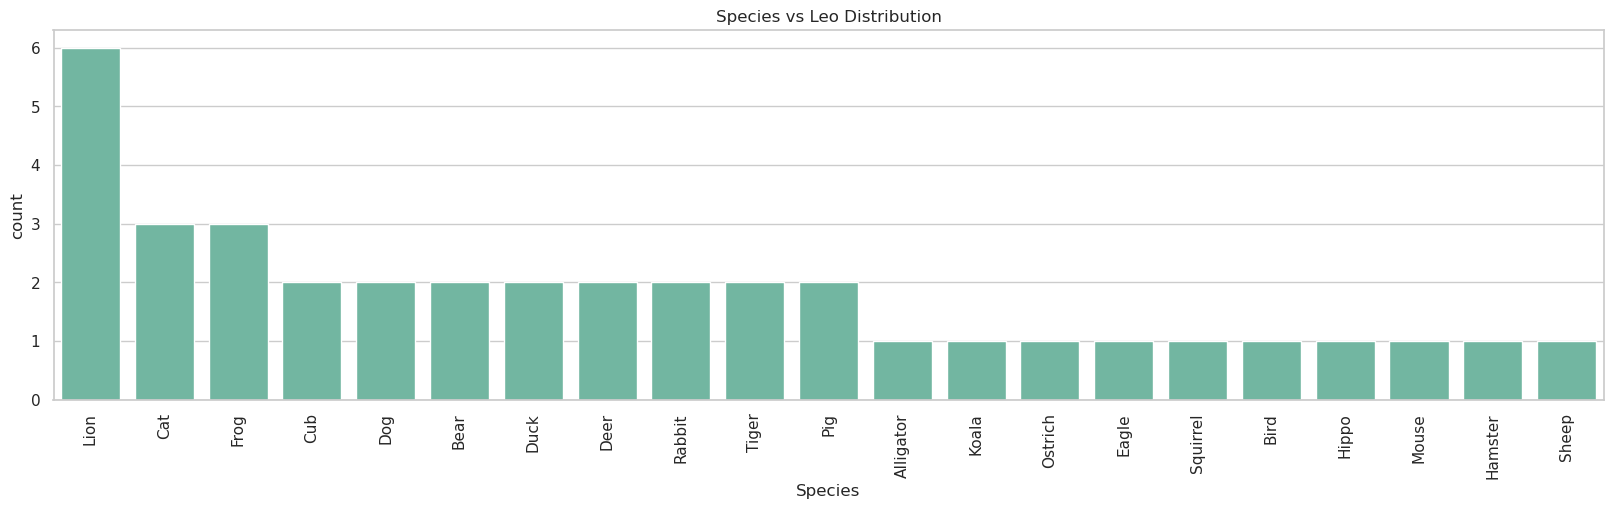


6 of the 7 lion villagers have Leo zodiac signs.


In [29]:
#What does the species distribution look like for Leo villagers? 
leo_villagers = villagers[villagers.zodiac_sign == 'Leo']

plt.figure().set_figwidth(20)
sns.countplot(x = 'Species', data = leo_villagers, order = leo_villagers['Species'].value_counts().index)
plt.title('Species vs Leo Distribution')
plt.xticks(rotation=90)
plt.show()

print()
print('6 of the 7 lion villagers have Leo zodiac signs.')

In [30]:
#What is the personality distirbution for Lions? 
lions = villagers[villagers.Species == 'Lion']
print(lions.Personality.value_counts())

Personality
Jock      3
Smug      2
Cranky    1
Lazy      1
Name: count, dtype: int64


### Conclusions <a class='anchor' id='conclusion'></a>
<ol>
<li>Female villager personalities:
    <ul>
        <li>Female ducks and cats have similar personality distributions - perhaps the game developers saw a lot of shared qualities in cats and ducks</li>
        <li>The leading personality among female bears is the Big Sister trait. This is on par with how humanity often characterizes female bears as being motherly and very protective of their young.</li>
        <li>Cats personalities are more commonly Peppy and Snooty and this also follows typical characteristics of real cats - full of attitude but also silly when excited.</li>
        <li>The most common personalities for female villagers are Normal and Snooty - is this possibly a reflection of stereoypes toward females?</li> 
    </ul>
</li>  
<li>Male villager personalities:
    <ul>
        <li>The leading personality for male bears is Cranky. This again seems to be on par with how humanity view bears as beings with massive appetites and needing large amounts of sleep.</li> 
        <li>Conversely, there are more male dogs with the Lazy personalities in comparison to cats. This seems like a direct contradiction toward in life observations between cats and dogs.</li> 
        <li>The most common personality for male villagers is Lazy. As with the female villagers, is this perhaps a reflection of common stereotypes of males?</li> 
<li>Overall, some species seem to have real life personality correlations, but the majority of the species appear to have random personality trait distributions.</li>
   </ul>      
</li> 
<li>Zodiac signs:
    <ul>
<li>Hobbies:
    <ul>
        <li>No male villagers have a hobby of Fashion, and Fashion is the most common female villager hobby. Meanwhile, the least common hobby for female villagers is Fitness, which happens to be the most common male villager hobby. Is this another sign the developers either knowingly or unknowningly included gender steretypes in the game?</li>
        <li>For the top 10 most common species, female villagers' top hobby is Fashion and male villagers' top hobby is Play instead of Fitness.</il>
        <li>When looking at the villager population as a whole, the hobby distribution is perfectly even between all hobbies.</il>
        <li>Species does not seem to have an effect hobby.</il>
    </ul>
</li>
<li>Zodiac Signs:
    <ul>
        <li>The Zodiac sign distribution is pretty well rounded, with Leo being the most common sign by a small percentage.</li>
        <li> Six of the seven Lion villagers are Leos.</li>
        <li>Per https://www.calendar.best/zodiac-sign-leo.html: 
            <ul>
                <li>"Leo is often described as confident, generous and charismatic. This sign likes to take the lead, create, perform and inspire others. Many Leo natives have a strong sense of loyalty and enjoy making the people around them feel special."</li> 
                <li>"The same fiery and proud energy can also create some challenges: Leo may sometimes be stubborn, dramatic or self-centered. This sign can find it hard to accept criticism and may want to be at the center of attention too often." </li>
                <li>"As the 5th sign of the zodiac, Leo is associated with self-expression, creativity and joy. It represents a phase where people affirm their identity, seek recognition and explore hobbies, love and pleasure..."</li> 
            </ul>
        <li>The seven lions have the following personalities: Jock, Smug, Cranky, and Lazy. It seems some of these personality characteristics may align with the Leo zodiac sign (i.e., confident, charismatic, leadership, dramatic, self-centered, etc.). For anyone who has placed Animal Crossing New Horizons, looking at the bigger picture, the Leo sign seems to be a solid representation of the villagers as whole.</li>
    </ul>
</li>
</ol>

In [33]:
villagers.to_csv('villagers_clean.csv')